In [1]:
import uproot
import pandas as pd
import numpy as np
import glob


In [2]:
import matplotlib.pyplot as plt
plt.style.use('default')
plt.style.use('belle2')

import os

In [3]:
import glob

base_path = "/share/storage/jykim/storage_b2/storage/reduced_ntuples/proc13_all/proc13_all_etapip_loose_v7_250205_Dp_dz"
base_path = "/share/storage/jykim/storage_b2/storage/reduced_ntuples/proc13_all/proc13_all_etapip_loose_v7_250205_Dp_dz_skimhad"

# base_path = "/share/storage/jykim/storage_b2/storage/reduced_ntuples/proc13/proc13_etaetapip_loose_v7_250122_temp"
# cm_elements = ["etahp_13_had_4S_off_v1", "etahp_13_had_4S_v3", "etahp_23_had_4S_off_v1", "etahp_23_had_4S_v1", "etahp_23_had_5Sscan_10657_v1", "etahp_23_had_5Sscan_10706_v1",\
               # "etahp_23_had_5Sscan_10751_v1", "etahp_23_had_5Sscan_10810_v1"]
cm_elements = ["etahp_13_4S_off_v1", "etahp_13_4S_v2", "etahp_23_4S_off_v1", "etahp_23_4S_v1", "etahp_23_5Sscan_10657_v1", "etahp_23_5Sscan_10706_v1",\
               "etahp_23_5Sscan_10751_v1", "etahp_23_5Sscan_10810_v1"]
cut_expression = "Dp_M>0"
tree_name = "etapip_gg"

file_list = []
for element in cm_elements:
    # pattern = f"{base_path}/{element}/*.root"
    pattern = f"{base_path}/{element}/{tree_name}/*.BCS.root"

    file_list += glob.glob(pattern)


dataframes = []
# Process each file
for file_name in file_list:
    # Load the ROOT file and tree
    file = uproot.open(file_name)
    tree = file[tree_name]

    # Specify the branches you want to extract
    # branches = ['Pip_pionID','Dp_Psum','Pip_genMotherID','etapip_Eta_genMotherID','Pip_genMotherPDG','etapip_Eta_genMotherPDG','Dp_cosHelicityAngleMomentum','Pip_dr',"Dp_isSignal","Dp_cosAngleBetweenMomentumAndVertexVectorInXYPlane", "Pip_p","Dp_CMS_p","etapip_Eta_p","CFT_prob","Dp_M","num_Dstar_no_nan",]  # Replace with actual branch names

    branches = ['Dp_M','Dp_CMS_cosTheta','Pip_cosTheta','Pip_p','Pip_charge']
    # Convert the selected branches to a Pandas DataFrame
    # df_temp = tree.arrays(branches, library="pd")
    df_temp = tree.arrays(
        branches,
        library="pd",
        entry_start=None,  # Optional: start at a specific entry
        entry_stop=None,   # Optional: stop at a specific entry
        filter_name=branches,  # Load only specified branches
        cut=cut_expression  # Apply the cut
    )
    # df_temp = tree.arrays(library="pd")

    # Append the DataFrame to the list
    dataframes.append(df_temp)

In [4]:
len(file_list)

72

In [21]:
df_proc13 = pd.concat(dataframes, ignore_index=True)


In [22]:
df_proc13.describe()

,Dp_M,Dp_CMS_cosTheta,Pip_cosTheta,Pip_p,Pip_charge
count,386645.000000,386645.000000,386645.000000,386645.000000,386645.000000
mean,1.785268,0.198677,0.439812,1.540058,-0.005201
std,0.152706,0.472123,0.470567,0.867538,0.999988
min,1.500002,-0.999633,-0.892108,0.400001,-1.000000
25%,1.660326,-0.174508,0.122825,0.796843,-1.000000
50%,1.773249,0.251949,0.595831,1.386679,-1.000000
75%,1.931801,0.599042,0.838875,2.127947,1.000000
max,2.099993,0.999976,0.976842,5.339994,1.000000


In [23]:
df_proc13 = df_proc13.query('Dp_M> 1.7 & Dp_M<2.1')


In [24]:
df_proc13.describe()

,Dp_M,Dp_CMS_cosTheta,Pip_cosTheta,Pip_p,Pip_charge
count,255502.000000,255502.000000,255502.000000,255502.000000,255502.000000
mean,1.873354,0.183809,0.433832,1.573141,-0.005057
std,0.103666,0.476197,0.474544,0.892183,0.999989
min,1.700003,-0.999633,-0.886036,0.400008,-1.000000
25%,1.775568,-0.195850,0.109086,0.806997,-1.000000
50%,1.872319,0.229366,0.590945,1.423000,-1.000000
75%,1.963831,0.588113,0.838319,2.175422,1.000000
max,2.099993,0.999976,0.974742,5.339994,1.000000


In [25]:
nan_columns = df_proc13.isnull().any()
print(nan_columns)

Dp_M               False
Dp_CMS_cosTheta    False
Pip_cosTheta       False
Pip_p              False
Pip_charge         False
dtype: bool


In [26]:
import glob

base_path = "/share/storage/jykim/storage_b2/storage/reduced_ntuples/MC15rd/etapip_eteeta/MC15rd_etaetapip_loose_v7_250122_skimhad_if_true"
# base_path = "/share/storage/jykim/storage_b2/storage/reduced_ntuples/MC15rd/etapip_eteeta/MC15rd_etaetapip_loose_v7_250122_skimhad_if_false"

# base_path = "/share/storage/jykim/storage_b2/storage/reduced_ntuples/MC15rd/etapip_eteeta/MC15rd_etaetapip_loose_v7_250122_noD0"

cm_elements = ["15rd_eta_e7_18_4S_v3", "15rd_eta_e20_b26_v1", "15rd_eta_e20_e26_4S_v2", "15rd_eta_e21_5S_scan_v1", "15rd_eta_mori_off_v1"]

cut_expression = "Dp_M>0"
tree_name = "etapip_gg"

file_list = []
for element in cm_elements:
    # pattern = f"{base_path}/{element}/*.root"
    # pattern = f"{base_path}/{element}/{tree_name}/*.BCS.root"
    # pattern = f"{base_path}/{element}/{tree_name}/train_Dp_dz/all/*.BCS.root"
    pattern = f"{base_path}/{element}/{tree_name}/train_Dp_dz/skimhad/*.BCS.root"


    file_list += glob.glob(pattern)


dataframes = []
# Process each file
for file_name in file_list:
    # Load the ROOT file and tree
    file = uproot.open(file_name)
    tree = file[tree_name]

    # Specify the branches you want to extract
    # branches = ['Pip_pionID','Dp_Psum','Pip_genMotherID','etapip_Eta_genMotherID','Pip_genMotherPDG','etapip_Eta_genMotherPDG','Dp_cosHelicityAngleMomentum','Pip_dr',"Dp_isSignal","Dp_cosAngleBetweenMomentumAndVertexVectorInXYPlane", "Pip_p","Dp_CMS_p","etapip_Eta_p","CFT_prob","Dp_M","num_Dstar_no_nan",]  # Replace with actual branch names

    branches = ['Dp_M','Dp_CMS_cosTheta','Pip_cosTheta','Pip_p','Pip_charge']
    # Convert the selected branches to a Pandas DataFrame
    # df_temp = tree.arrays(branches, library="pd")
    df_temp = tree.arrays(
        branches,
        library="pd",
        entry_start=None,  # Optional: start at a specific entry
        entry_stop=None,   # Optional: stop at a specific entry
        filter_name=branches,  # Load only specified branches
        cut=cut_expression  # Apply the cut
    )
    # df_temp = tree.arrays(library="pd")

    # Append the DataFrame to the list
    dataframes.append(df_temp)

In [27]:
df_mc15rd = pd.concat(dataframes, ignore_index=True)


In [28]:
df_mc15rd.describe()

,Dp_M,Dp_CMS_cosTheta,Pip_cosTheta,Pip_p,Pip_charge
count,1.339533e+06,1.339533e+06,1.339533e+06,1.339533e+06,1.339533e+06
mean,1.781461e+00,1.850100e-01,4.022090e-01,1.589260e+00,-4.142488e-03
std,1.515869e-01,4.772635e-01,4.655704e-01,8.286915e-01,9.999918e-01
min,1.500000e+00,-9.989309e-01,-8.974629e-01,4.000002e-01,-1.000000e+00
25%,1.656997e+00,-1.956713e-01,7.339001e-02,8.995734e-01,-1.000000e+00
50%,1.765867e+00,2.369245e-01,5.312865e-01,1.468009e+00,-1.000000e+00
75%,1.938214e+00,5.912080e-01,8.010053e-01,2.142489e+00,1.000000e+00
max,2.099998e+00,9.999999e-01,9.736712e-01,5.481539e+00,1.000000e+00


In [29]:
df_mc15rd = df_mc15rd.query('Dp_M> 1.7 & Dp_M<2.1')


In [30]:
df_mc15rd.describe()

,Dp_M,Dp_CMS_cosTheta,Pip_cosTheta,Pip_p,Pip_charge
count,869482.000000,869482.000000,869482.000000,869482.000000,869482.000000
mean,1.871713,0.170808,0.393100,1.624069,-0.003892
std,0.102263,0.481680,0.469635,0.848894,0.999993
min,1.700000,-0.998931,-0.897463,0.400000,-1.000000
25%,1.772982,-0.215495,0.054837,0.919592,-1.000000
50%,1.872926,0.216376,0.520632,1.506533,-1.000000
75%,1.964193,0.580598,0.797869,2.187563,1.000000
max,2.099998,0.999991,0.973671,5.481539,1.000000


In [31]:
nan_columns = df_mc15rd.isnull().any()
print(nan_columns)

Dp_M               False
Dp_CMS_cosTheta    False
Pip_cosTheta       False
Pip_p              False
Pip_charge         False
dtype: bool


In [32]:
from plothist import make_hist, plot_hist
from plothist import plot_two_hist_comparison, add_luminosity


In [33]:
tree_to_compare = "etapip_gg"
plt.rcParams['font.family'] = 'DejaVu Sans'


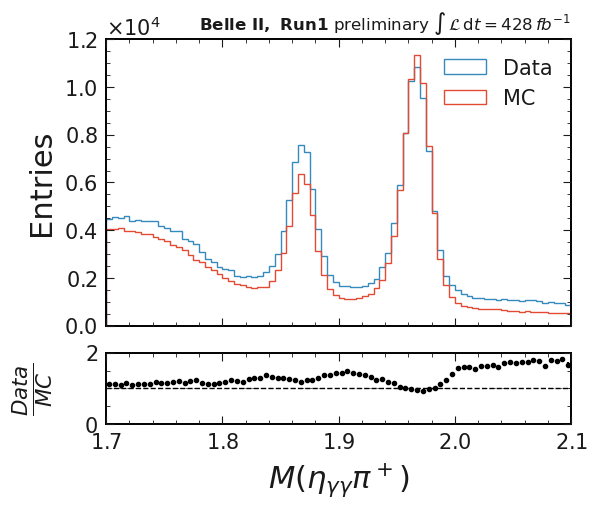

In [34]:
name = "Dp_M"
category = "category"
xlabel = r"$M(\eta_{\gamma\gamma} \pi^+)$"

# x1 = df[name][df[category] == 1]
# x2 = df[name][df[category] == 2]

x1 = df_proc13[name]
x2 = df_mc15rd[name]

# x_range = (min(min(x1), min(x2)), max(max(x1), max(x2)))
# x_range = (min(min(x1), min(x2)),5.1)
x_range = (1.7,2.1)

h1 = make_hist(x1, bins=80, range=x_range, weights=1)
h2 = make_hist(x2, bins=80, range=x_range, weights=1/4)


# Default comparison is ratio
fig, ax_main, ax_comparison = plot_two_hist_comparison(
    h1,
    h2,
    xlabel=xlabel,
    ylabel="Entries",
    h1_label="Data",
    h2_label="MC",
    comparison="split_ratio",
)

add_luminosity(
    collaboration="Belle II, Run1", ax=ax_main, lumi=428, lumi_unit="fb", preliminary=True
)
fig.savefig(f"proc13_MC15rd_{tree_to_compare}_{name}_skimhad.png", bbox_inches="tight")